In [1]:
%%HTML
<script src="require.js"></script>

In [2]:
from IPython.display import HTML, display, Markdown, Image
HTML('''<script src="https://cdnjs.cloudflare.com/ajax/libs/jquery/2.0.3/jquery.min.js "></script><script>
code_show=true; 
function code_toggle() {
if (code_show){
$('div.jp-CodeCell > div.jp-Cell-inputWrapper').hide();
} else {
$('div.jp-CodeCell > div.jp-Cell-inputWrapper').show();
}
code_show = !code_show
} 
$( document ).ready(code_toggle);</script><form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>
''')

In [3]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# because i need to import this nlng rather than pyfim huhuhu
try:
    import pyfpgrowth
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyfpgrowth"])
    import pyfpgrowth

from sklearn.preprocessing import MultiLabelBinarizer
from collections import defaultdict
import itertools

import os


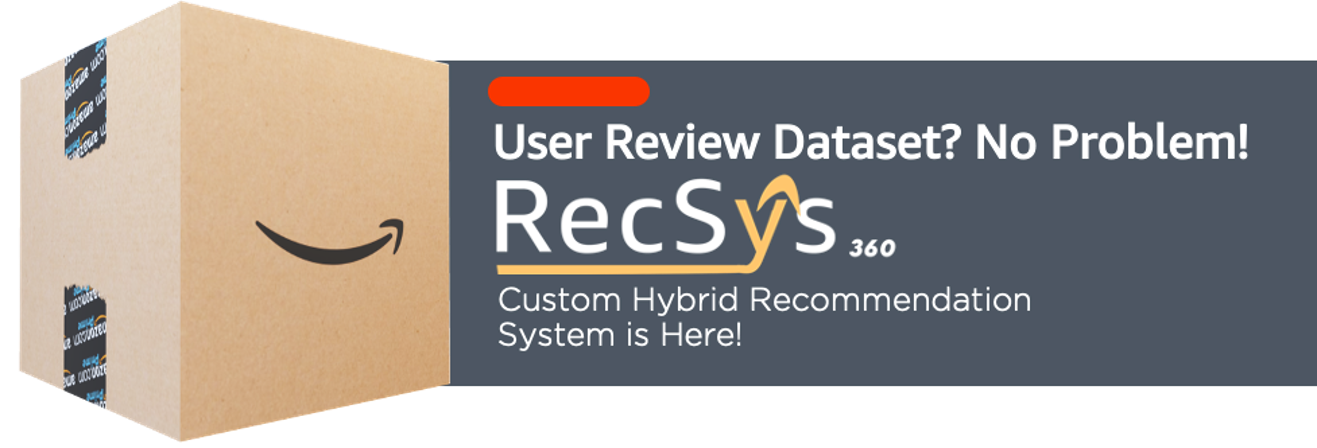

<a id='ExecSum'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">I. EXECUTIVE SUMMARY</h1>

The Philippines faces a major public health challenge due to diet-related illnesses among older adults, contributing to a lower average life expectancy of 70 years. Promoting healthy eating among Filipino seniors requires identifying key ingredient patterns that are both nutritious and practical for daily meal preparation. This study aims to distinguish ingredient combinations in healthy recipes from those in non-healthy recipes to inform the development of a senior-friendly cookbook.

Using the food-com-recipes dataset containing 231,637 recipes, recipes tagged with “healthy” or “healthy-2” were classified as healthy, while all others were considered non-healthy. Exploratory Data Analysis (EDA) confirmed that healthy recipes contained lower levels of total fat, saturated fat, sugar, and sodium, validating their suitability for health-focused analysis. Frequent Itemset Mining (FIM) via the FP-Growth algorithm was applied separately to healthy and non-healthy recipes using a relative minimum support of 0.015 and a minimum confidence of 0.75 to extract meaningful and reliable patterns.

The analysis revealed 265 frequent itemsets for non-healthy recipes and 227 for healthy recipes. Salt consistently emerged as the most frequent ingredient, with relative supports of 0.365 in non-healthy recipes and 0.389 in healthy ones, confirming its role as a universal base seasoning. Healthy recipes, however, featured unique combinations such as vegetable oil (relative support of 0.057) and whole wheat flour (relative support of 0.025), suggesting substitutions that reduce saturated fat and improve nutritional quality. A Jaccard similarity index of 0.48 between frequent ingredient combinations in non-healthy and healthy recipes indicates moderate overlap, highlighting distinct health-oriented patterns while maintaining familiar flavors.

Based on these findings, cookbook authors and nutrition advocates are encouraged to replace or reduce salt with low-sodium alternatives or herbs, substitute butter with healthier fats such as olive oil or avocado, and highlight natural sweeteners like honey to lower added sugar. Future studies could integrate nutritional metrics directly into the mining process to discover ingredient combinations that are both frequent and nutritionally balanced, further supporting health-conscious recipe development for seniors.


<a id='Introduction'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">II. Introduction</h1>

The Philippines faces a major public health concern because of its notably low life expectancy (an average of 70 years) that occurs due to diet-related illnesses like diabetes, hypertension, cardiovascular disorders, and more (Gumaru, n.d.). Older Filipinos often experience nutritional imbalances from reduced metabolism, limited mobility, and poor dietary habits, making the promotion of healthy eating a national priority. The World Health Organization (WHO) and the Department of Health (DOH) suggests that adults should limit their total fat intake to 2-5 tablespoons daily, consume less than 6% of total calories from saturated fat, and keep added sugar within 4-5 tablespoons per day to reduce the risk of chronic diseases (2025). Both local and international research highlight that balanced and nutrient-based diets are directly related with longer life expectancy and improved quality of life among older adults. 

In line with this, the study aims to develop a cookbook of healthy recipes for Filipino seniors. **The core problem is identifying which ingredients combinations are most common in healthy recipes and whether these recipes are sufficiently distinct from non-healthy recipes**. Minimizing the number of unique ingredients ensures that the seniors can prepare nutritious meals without buying an excessive variety of items and going to the store that often. Using Frequent Itemset Mining, core ingredients that can serve as a reliable base for daily meals, simplifying the process of consistently cooking healthy dishes were identified. The objectives are then three-fold:
1. Validate recipe healthiness through exploratory data analysis of ingredients and health-related tags
2. Find frequent ingredient combinations and association rules using Frequent Itemset Mining for healthy recipes and for non-healthy recipes separately
3. Compare healthy and non-healthy recipes by analyzing and contrasting their frequent ingredient sets.


<a id='Methodology'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">III. METHODOLOGY</h1>

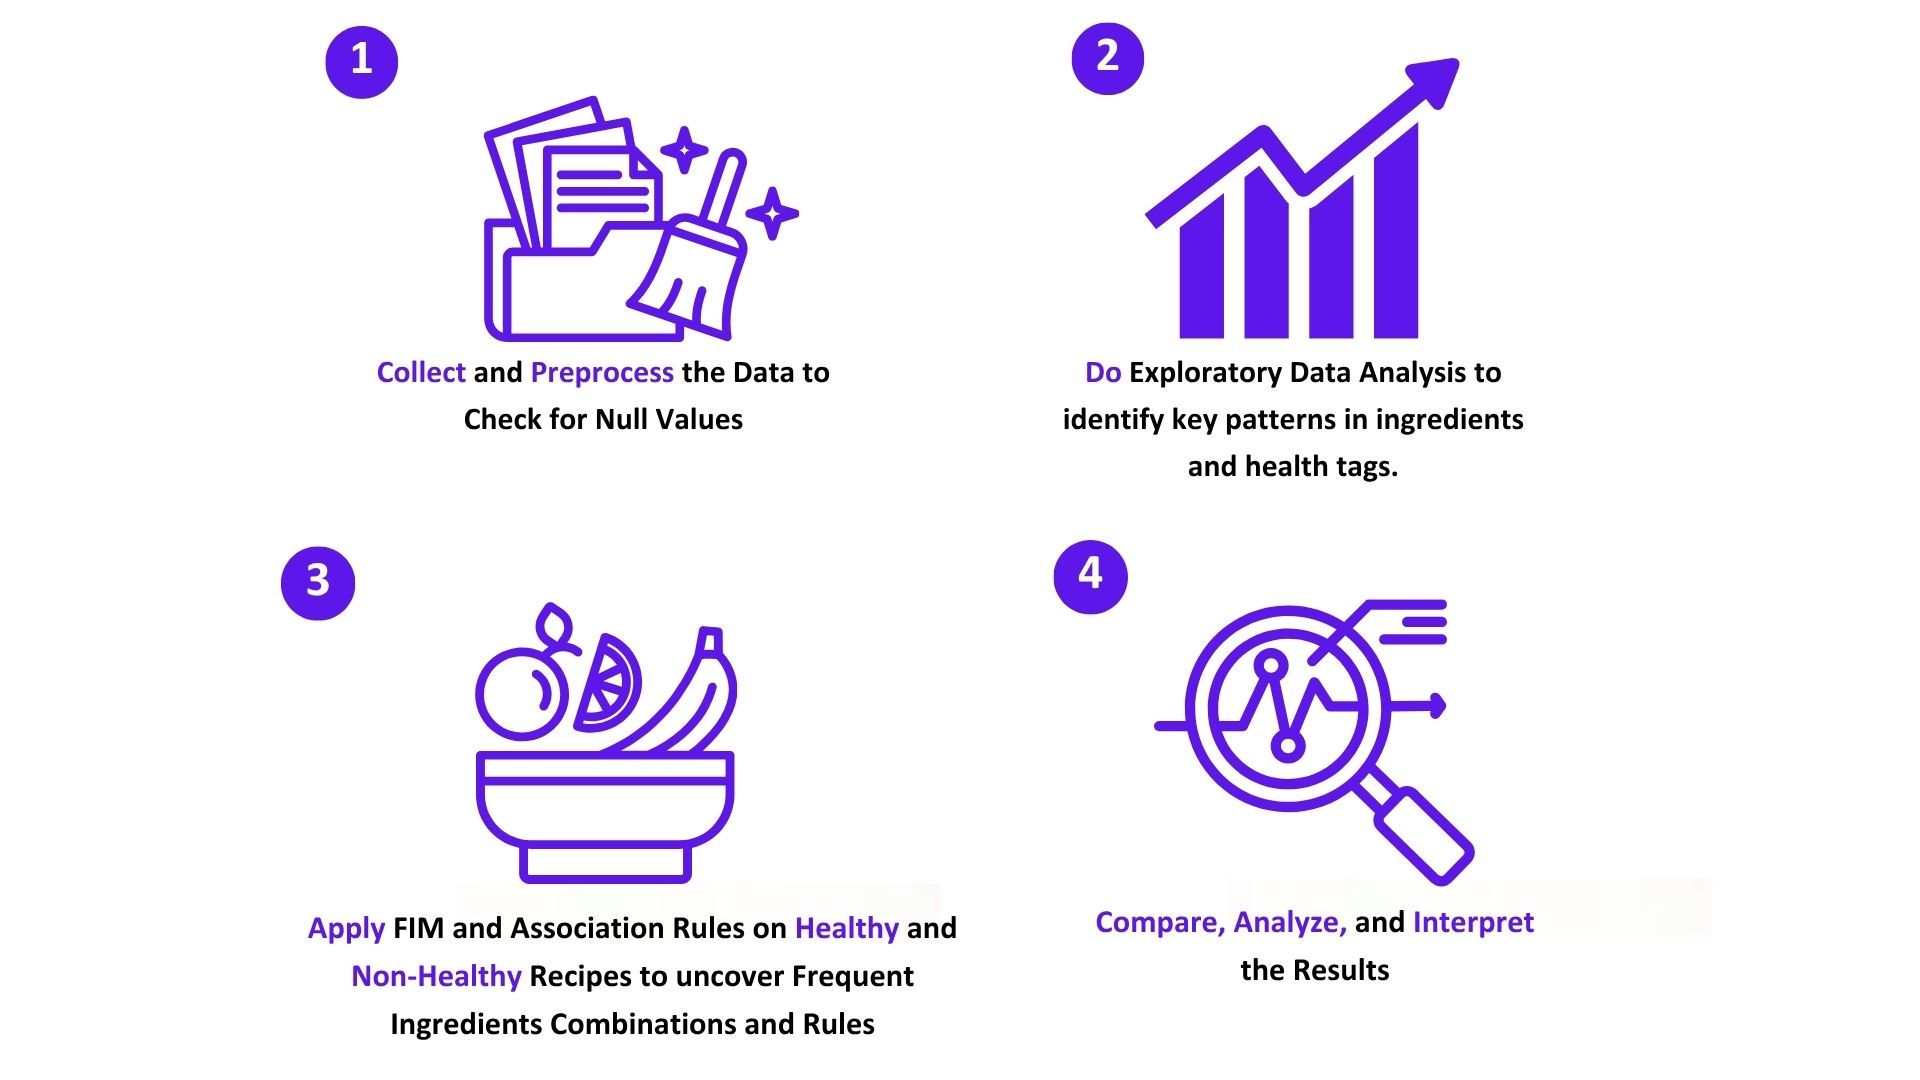
<left><span style="font-size:14px"><b>Figure 1. </b>Methodology</span></left>

*3.1 Collect and Preprocess the Data to Check for Null Values*

The data was collected and checked for null values in relevant columns, and none were found. Irrelevant columns were dropped while the relevant columns for analysis are discussed later.

*3.2 Do Exploratory Data Analysis to identify key patterns in ingredients and health tags. (EDA)*

The EDA focused on two main objectives. First, the most common ingredients across all recipes were identified using a bar chart to show frequency patterns. Second, healthy recipes, which were defined as those with a tag containing the word “health” (healthy or healthy-2), were compared to non-healthy recipes using histograms of nutritional values to check if they are indeed healthier. Healthy foods comprise about 20% of the sample. 

*3.3 Apply FIM and Association Rules on Healthy and Non-Healthy Recipes to uncover Frequent Ingredients Combinations and Rules*

Frequent Itemset Mining (FIM) and association rule analysis were applied separately to healthy and non-healthy recipes to uncover common ingredient combinations and relationships. This approach identifies which ingredients tend to appear together and reveals patterns specific to each category, helping to understand typical recipe structures and dietary trends in the dataset. The python module used is `pyfpgrowth` because it is readily available via `pip install`, which allowed the analysis to proceed while Jojie was unavailable.

*3.4 Compare, Analyze, and Interpret the Results*

The frequent ingredient combinations of healthy and non-healthy recipes were compared using the Jaccard index to see if they are sufficiently different. Based on the frequent itemsets found, ingredient-based recommendations were generated to suggest substitutions or combinations that could make recipes healthier.


<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">IV. Collect and Preprocess the Data to Check for Null Values</h1>

The data collection section involves three key steps:
1. Identifying the data source;
2. Collecting and storing the data as a CSV; and
3. Describing the data.

<h2 style="color:#ff9a00">A. Data Source</h2>

The team utilized the food-com-recipes dataset, which is publicly available through the ‘jojie-collected’ repository in the /mnt/data/public directory maintained by the Asian institute of Management. The dataset, located at `/mnt/data/public/food-com-recipes/RAW_recipes.csv`, contains various recipes and reviews.


<h2 style="color:#ff9a00">B. Data Collection and Database Creation</h2>

While the team retrieved the data using the Jojie public dataset repository, it is also important to acknowledge the original data source and its collection method. The food-com-recipes dataset is a publicly available collection of over 180 thousand recipes and 700 thousand recipe reviews which covers 18 years of user interactions and uploads from the website Food.com, previously known as Genius Kitchen. The dataset was accessed in CSV format (294.52 MB) and processed using the Pandas library in Python for further analysis.


<h2 style="color:#ff9a00">C. Data Description</h2>

The following features were used and considered relevant for this report:

The following features are contained in the food-com-recipes Dataset with a shape of 231637 and 12 columns but we will only focus on 3 important columns listed in Table 1

<div align="center">

| Feature     | Description                                                                 | Data Type      |
|------------|-----------------------------------------------------------------------------|---------------|
| Tags       | List of words and phrases to describe the recipe                             | List (string) |
| Nutrition  | List of Nutritional Values — calories, total fat, sugar, sodium, protein, saturated fat, and carbohydrates | List (integer) |
| Ingredients | List of ingredients used in the recipe                                      | List (string) |

<left><span style="font-size:14px"><b>Table 1. </b>Features from food-com-recipes</span></left>

</div>

<h2 style="color:#ff9a00">D. Preprocess the Data</h2>

As shown in Table 2, no null values were removed because the relevant columns are complete. Nulls in the description column merely indicate that a customer chose not to provide feedback and do not affect the analysis. Similarly, one recipe, which does not have a name, still has a non-empty ingredients and tag list, so it was still usable. Additionally, because the dataset was originally stored in a CSV file, the nutrition, tags, and ingredients columns were encoded as strings instead of actual lists. These were therefore converted into proper list formats for accurate processing.

In [4]:
#folder_path = "/mnt/data/public/food-com-recipes/RAW_recipes.csv"
folder_path = "data/RAW_recipes.csv"
df = pd.read_csv(folder_path)

In [5]:
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ["Column", "Number of Nulls"]


display(null_counts)
display(Markdown("**Table 1.** Number of Null Values per Column"))


,Column,Number of Nulls
0,name,1
1,id,0
2,minutes,0
3,contributor_id,0
4,submitted,0
5,tags,0
6,nutrition,0
7,n_steps,0
8,steps,0
9,description,4979


**Table 1.** Number of Null Values per Column

In [6]:
# Convert the tags into a list
df["nutrition"] = df["nutrition"].apply(json.loads)

# Convert the tags into
df['tags'] = df['tags'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)
df['ingredients'] = df['ingredients'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)

<a id='Exploration'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">V. Exploratory Data Analysis</h1>

Across all recipes, salt, butter, and sugar are the most frequently used ingredients, followed by staples like onion, water, eggs, and olive oil. Common items such as flour, milk, garlic, and pepper indicate a reliance on basic seasonings and foundational components. This pattern reflects typical everyday cooking and helps identify core ingredients for meal planning, especially for seniors.


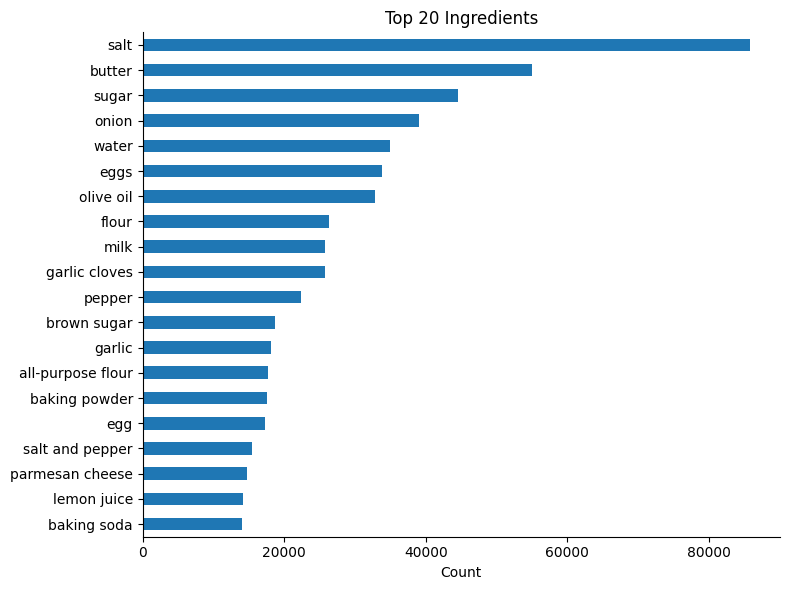

**Figure 2.** Top 20 Ingredients Over All Recipes

In [7]:
top_ingredients = (
    df["ingredients"]
    .explode()
    .value_counts()[:20]
    .sort_values(ascending=True)
)

ax = top_ingredients.plot(kind="barh", figsize=(8, 6))
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title("Top 20 Ingredients")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Save the figure
plt.tight_layout()
plt.savefig("figures/top_20_ingredients.png", dpi=300)
plt.show()

display(Markdown("**Figure 2.** Top 20 Ingredients Over All Recipes"))

A food is considered healthy if it has a tag containing the word “health,” which in this dataset corresponds to `healthy` or `healthy-2`. Recipes with at least one such tag are included in the df_healthy subset for analysis. There are 45,188 healthy recipes, accounting for 20% of the dataset.

After defining healthy foods, a sanity check was performed by comparing the distribution of nutritional values between the non-healthy and healthy subsets. Total fat, saturated fat, sugar, and sodium are lower in the healthy subset compared to the non-healthy subset, which aligns with dietary recommendations for reducing the risk of cardiovascular disease, obesity, and other diet-related conditions (American Heart Association, 2024; U.S. Department of Agriculture & U.S. Department of Health and Human Services, 2025). This confirms that filtering by “health”-related tags is sufficient for analysis.


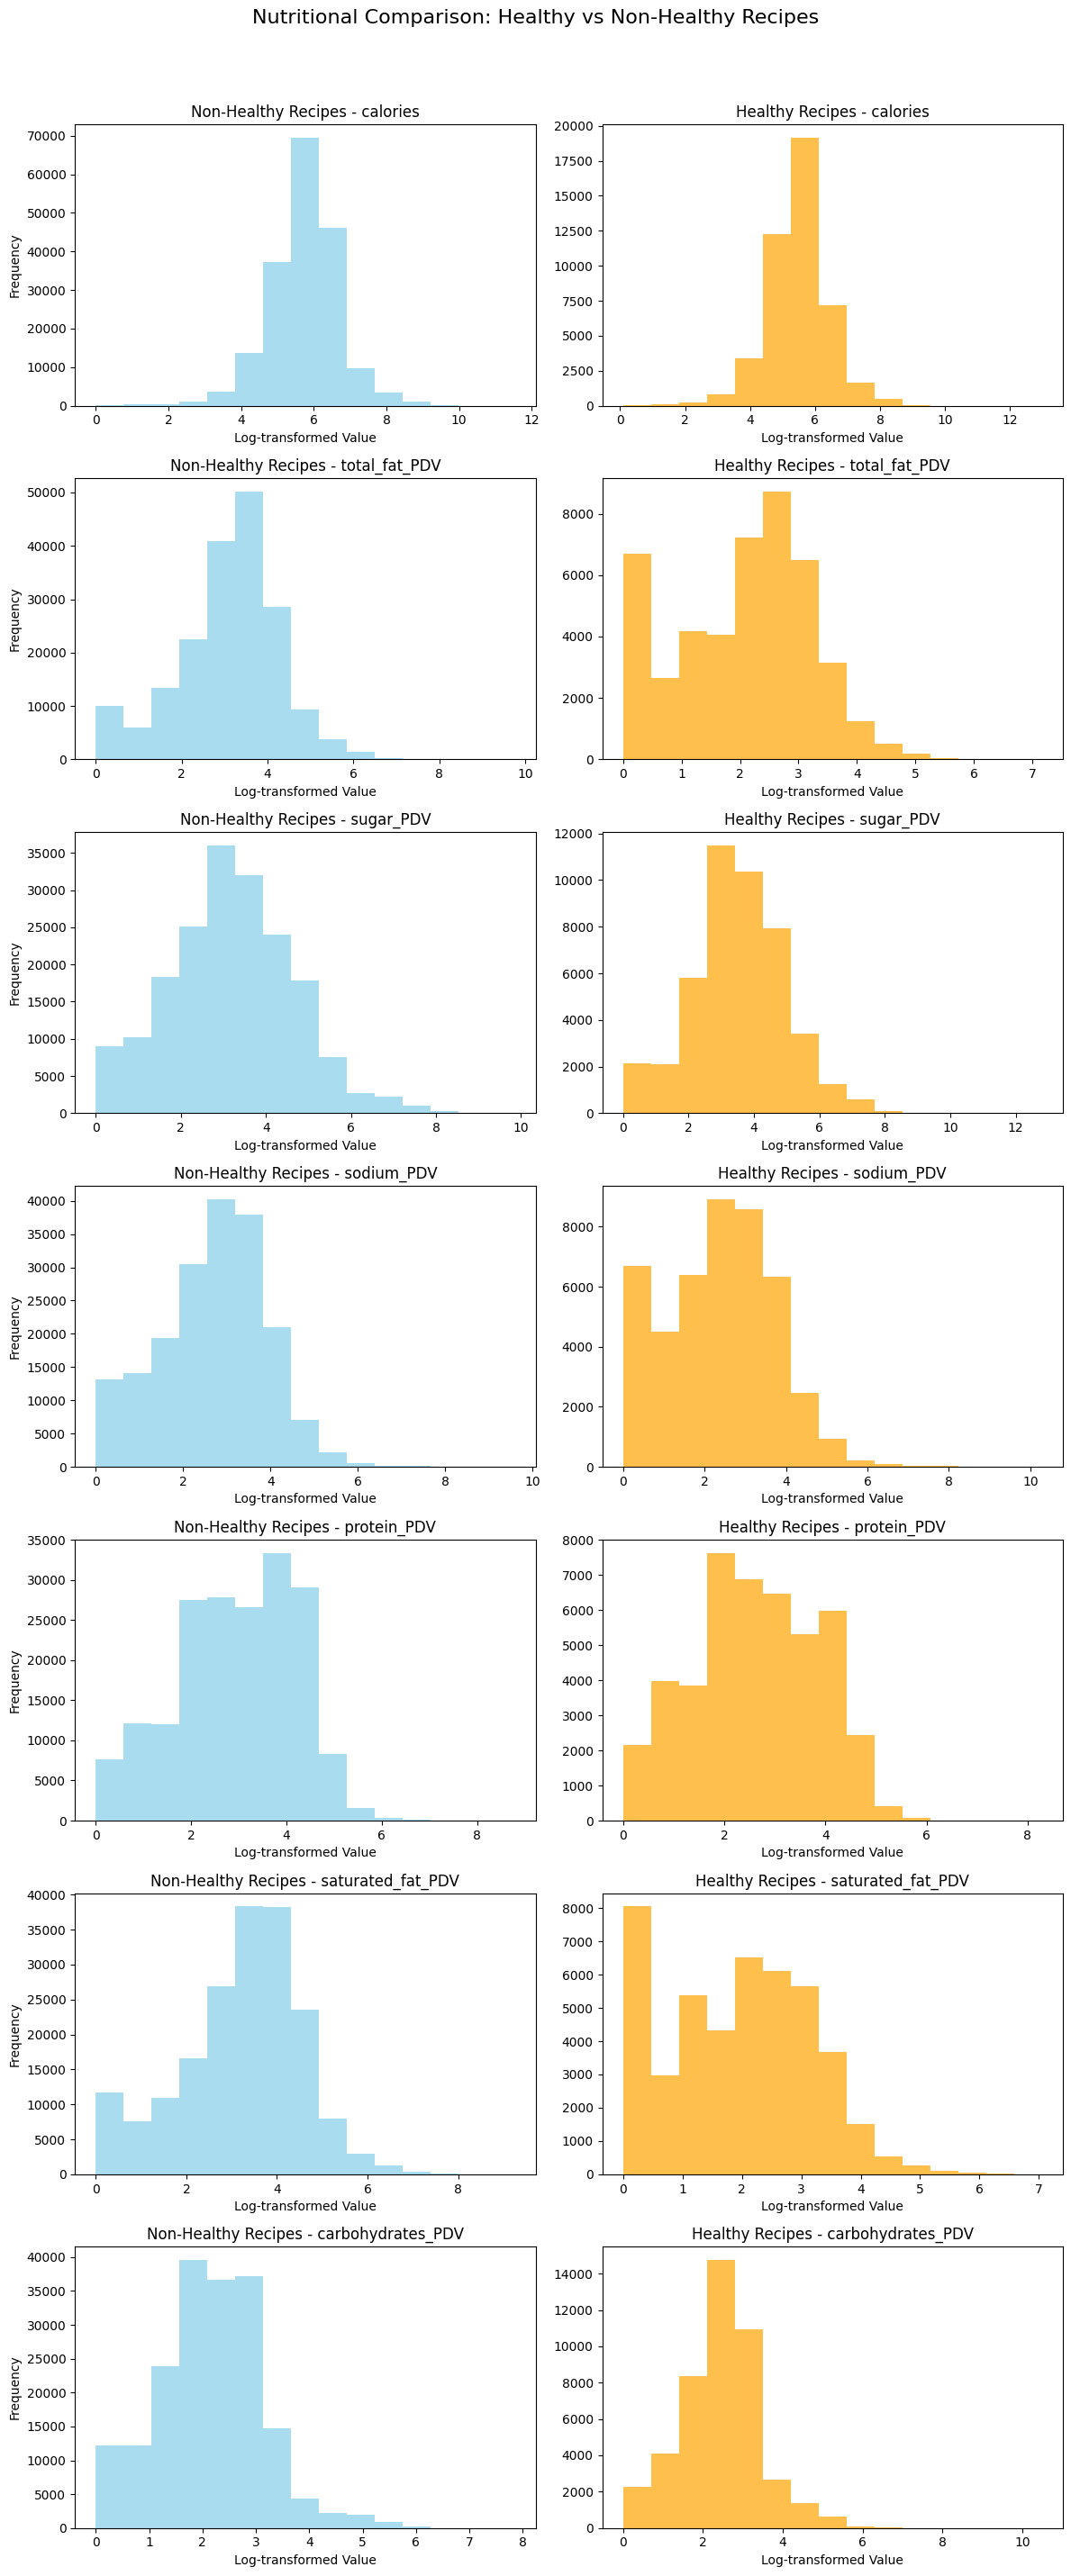

**Figure 3.** Nutritional Comparison between Non-Healthy and Healthy Recipes

In [8]:
# Create the tags presence matrix
mlb = MultiLabelBinarizer()
tags_matrix = mlb.fit_transform(df['tags'])
df_tags_matrix = pd.DataFrame(tags_matrix, columns=mlb.classes_, index=df.index)

# Automatically find all tags that contain "health"
health_related_tags = [
    col for col in df_tags_matrix.columns if 'health' in col.lower()
]

# Create a boolean mask for healthy-tagged foods
is_health_tag = df_tags_matrix[health_related_tags].any(axis=1)

# Filter the healthy foods
df_healthy = df[is_health_tag]
df_non_healthy = df[~is_health_tag]

# Save the indices (or IDs) of healthy foods to a CSV file
df_healthy.index.to_series().to_csv(
    'data/is_healthy_food.csv',
    index=False,
    header=False
)

nutrition_cols = [
    "calories",
    "total_fat_PDV",
    "sugar_PDV",
    "sodium_PDV",
    "protein_PDV",
    "saturated_fat_PDV",
    "carbohydrates_PDV",
]

df_healthy_nutritions = df_healthy["nutrition"].apply(pd.Series)
df_healthy_nutritions.columns = nutrition_cols

df_non_healthy_nutritions = df_non_healthy["nutrition"].apply(pd.Series)
df_non_healthy_nutritions.columns = nutrition_cols

# -------------------------
# Plot comparison
# -------------------------
selected_cols = nutrition_cols

fig, axes = plt.subplots(
    nrows=len(selected_cols),
    ncols=2,
    figsize=(12, 4 * len(selected_cols))
)
fig.suptitle("Nutritional Comparison: Healthy vs Non-Healthy Recipes", fontsize=16, y=1.02)

for i, col in enumerate(selected_cols):
    # Non-healthy recipes
    axes[i, 0].hist(
        np.log1p(df_non_healthy_nutritions[col].dropna()),
        bins=15,
        alpha=0.7,
        color="skyblue"
    )
    axes[i, 0].set_title(f"Non-Healthy Recipes - {col}")
    axes[i, 0].set_xlabel("Log-transformed Value")
    axes[i, 0].set_ylabel("Frequency")

    # Healthy recipes
    axes[i, 1].hist(
        np.log1p(df_healthy_nutritions[col].dropna()),
        bins=15,
        alpha=0.7,
        color="orange"
    )
    axes[i, 1].set_title(f"Healthy Recipes - {col}")
    axes[i, 1].set_xlabel("Log-transformed Value")

plt.tight_layout()
plt.show()

display(Markdown("**Figure 3.** Nutritional Comparison between Non-Healthy and Healthy Recipes"))

<a id='Apply FIM'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">VI. Apply FIM and Association Rules on Healthy and Non-Healthy Recipes to uncover Frequent Ingredients Combinations and Rules</h1>

<a id='Clustering'></a>
<h2 style="color:#ff9a00">A. Apply FIM to Ingredients for Non-Healthy Food</h2>

Frequent Itemset Mining (FIM) was separately applied to non-healthy and healthy recipes to identify frequent ingredient combinations. FP-Growth was chosen because it is efficient for large datasets, avoiding the generation of candidate itemsets that do not actually occur in the data and ensuring that only relevant frequent itemsets are considered. 

In order to know the proper values we should use for our parameters, particularly minimum relative support and minimum confidence, we did hyperparameter tuning. We used heuristic or exploratory tuning where the distribution of itemset supports is visualized using a histogram, and a reasonable threshold is chosen using the elbow method. This approach was chosen because it balances coverage and noise. Setting the threshold too low would produce many rare itemsets while setting it too high will miss meaningful ingredient combinations. Through the elbow point, we can get the parameters that capture the most frequent and meaningful combinations without being overwhelmed by irrelevant patterns. We ensured to start from a non-zero value (0.1%) to avoid generating too many itemsets.

As seen from Figure 4, 0.015 is the point where support begins to decrease sharply, indicating that this is the most appropriate minimum support value to focus on itemsets that appear in a sufficient number of recipes to be meaningful, while filtering out combinations that are too infrequent to provide useful insights.


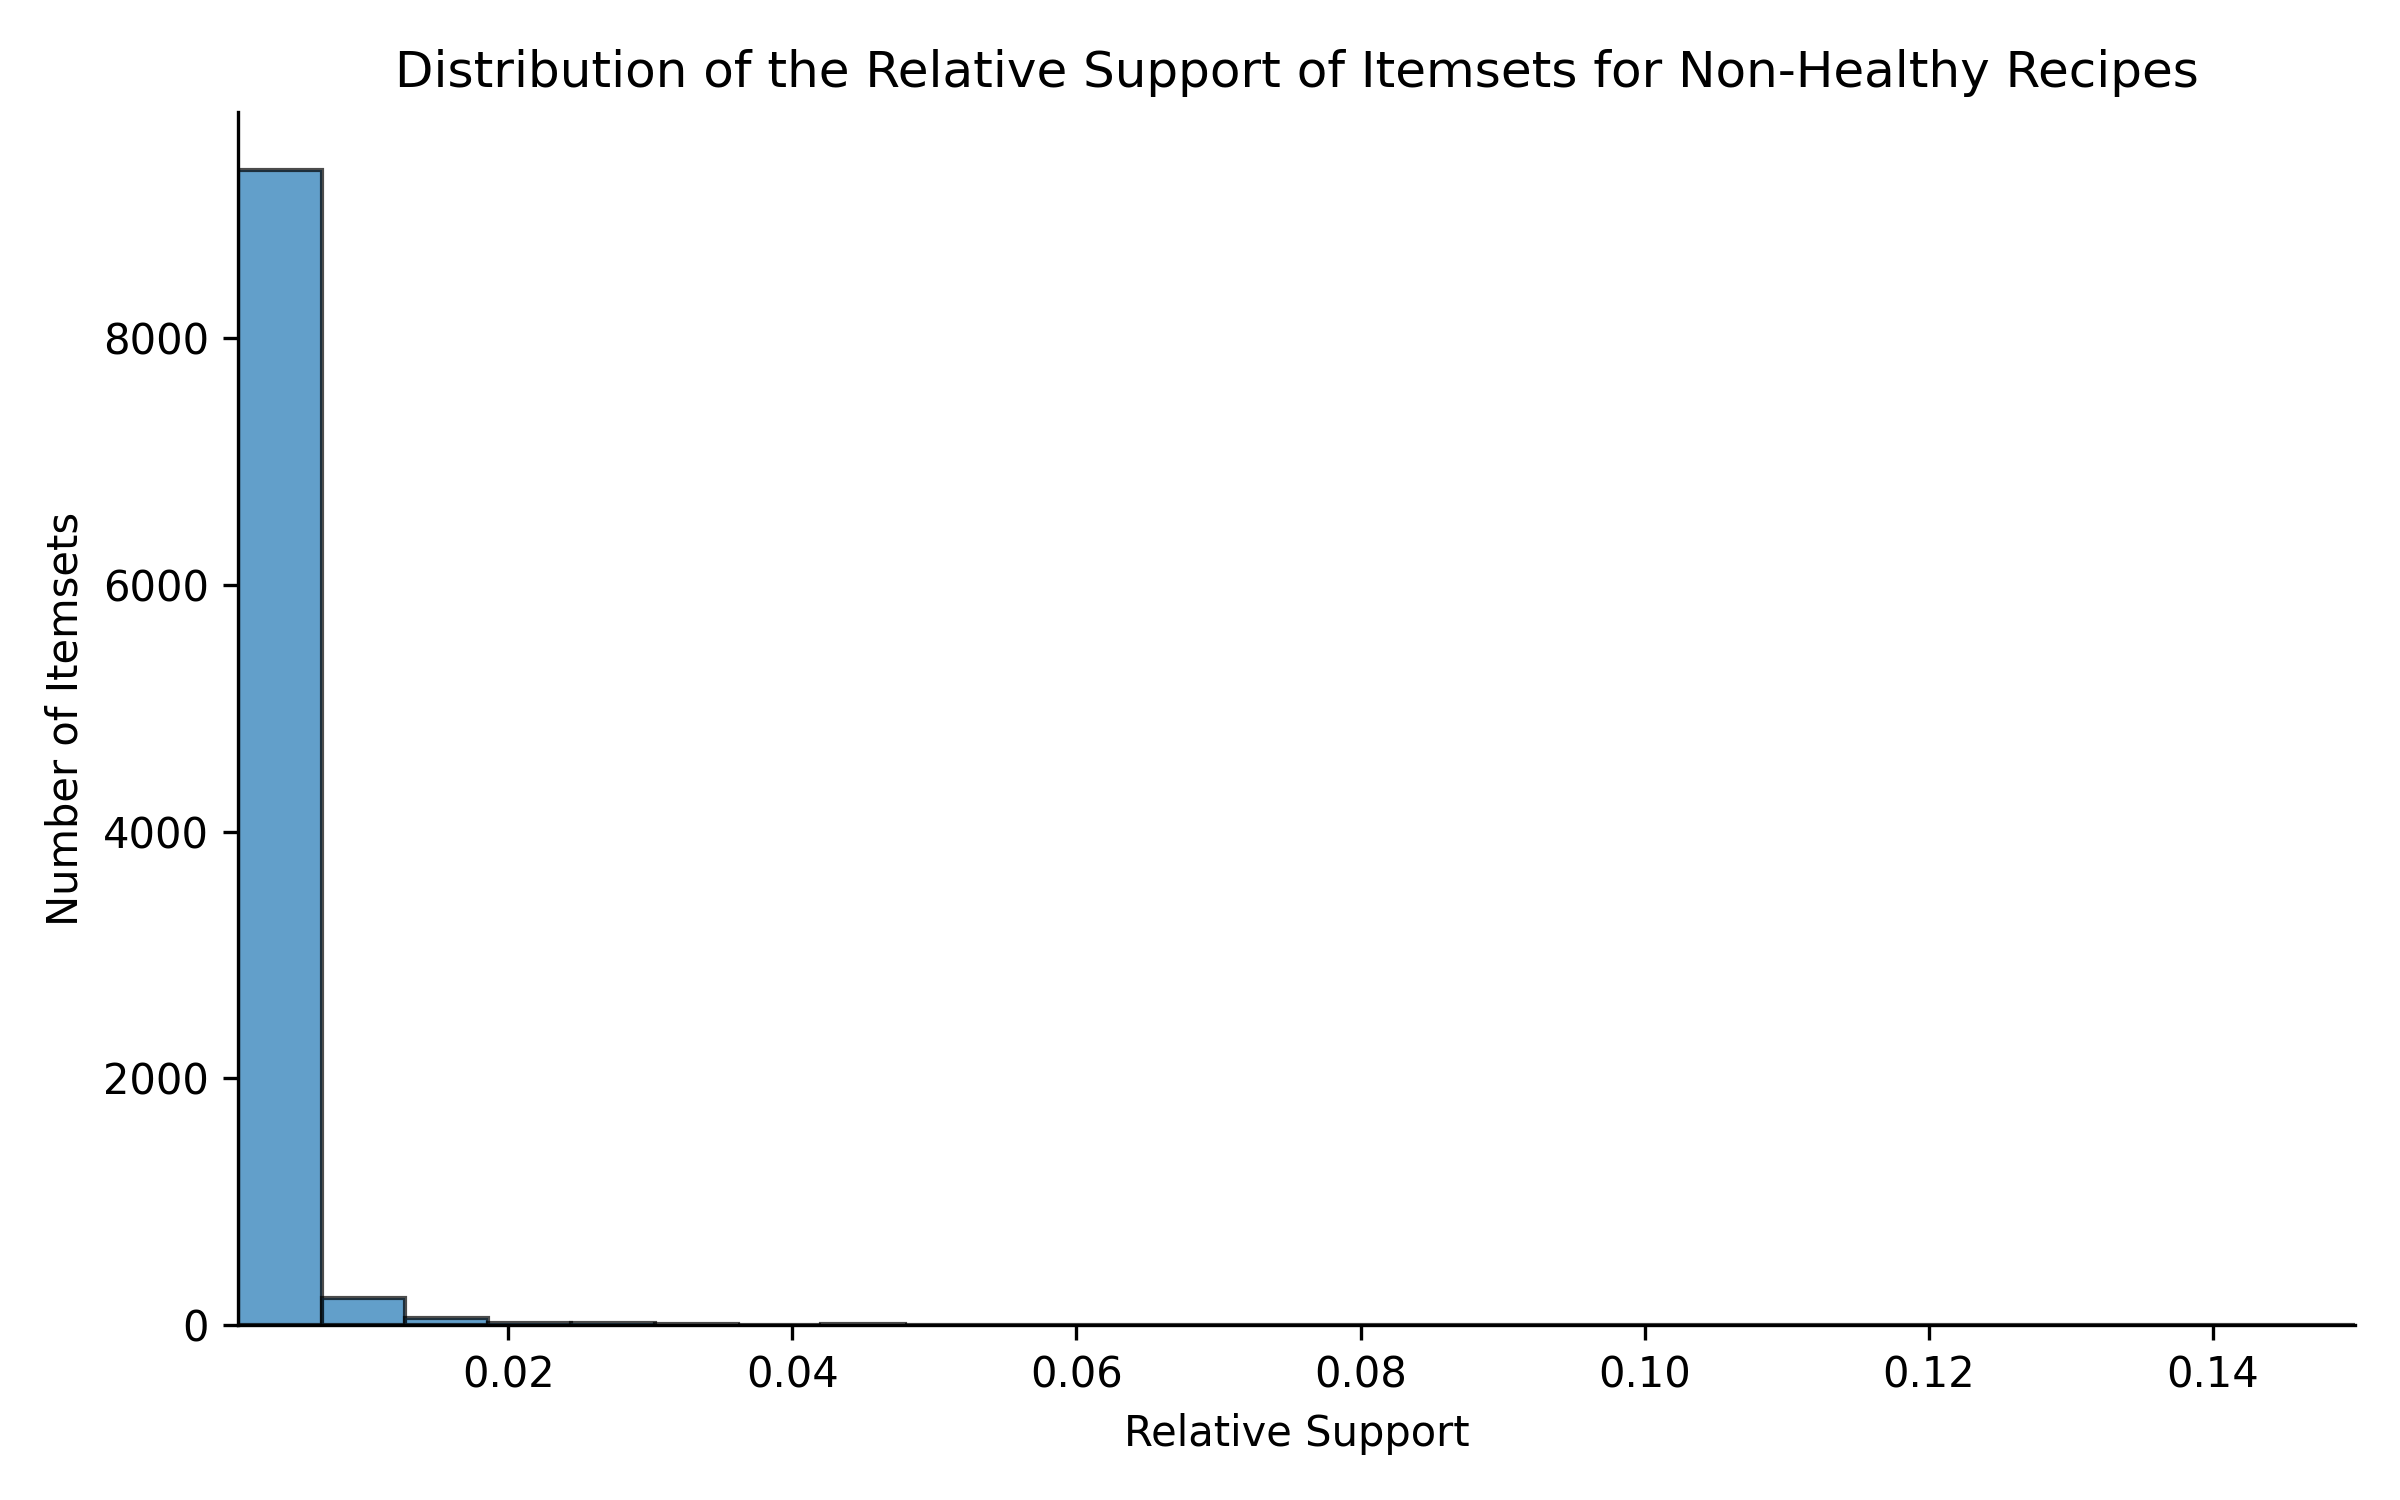

**Figure 4.** Distribution of the Relative Support of Itemsets for Non-Healthy Recipes

In [9]:
file_path = 'figures/relsup_non_healthy.png'

if os.path.exists(file_path):
    # If file exists, just display it
    display(Image(filename=file_path))
else:
    # --- Prepare transactions (list of ingredient lists) ---
    transactions = df_non_healthy['ingredients'].tolist()

    # --- Set minimum support threshold ---
    min_support = 0.001  # you can adjust this

    # --- Compute absolute minimum support count ---
    minsup_count = max(1, int(len(transactions) * min_support))

    # --- Find frequent itemsets ---
    patterns = pyfpgrowth.find_frequent_patterns(transactions, minsup_count)

    # --- Convert to DataFrame ---
    itemset_freq = pd.DataFrame({
        'itemset': list(patterns.keys()),
        'count': list(patterns.values())
    })
    itemset_freq['support'] = itemset_freq['count'] / len(df)

    # --- Filter supports (just to zoom in) ---
    itemset_freq = itemset_freq[itemset_freq['support'] >= 0.001]

    # --- Show summary statistics ---
    print(itemset_freq['support'].describe())

    # --- Plot histogram ---
    plt.figure(figsize=(8, 5))
    plt.hist(itemset_freq['support'], bins=50, edgecolor='black', alpha=0.7)
    plt.title("Distribution of the Relative Support of Itemsets for Non-Healthy Recipes")
    plt.xlabel("Relative Support")
    plt.ylabel("Number of Itemsets")
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    # --- Adjust x-axis and layout ---
    plt.xlim(0.001, 0.15)
    plt.margins(x=0.02, y=0.05)
    plt.tight_layout()
    plt.savefig(file_path, dpi=300)
    plt.show()

display(Markdown("**Figure 4.** Distribution of the Relative Support of Itemsets for Non-Healthy Recipes"))


In [10]:
# --- Parameters ---
min_support = 0.015
min_confidence = 0.55

# --- Step 1: Compute minsup count ---
num_transactions = len(df_non_healthy['ingredients'])
minsup_count = max(1, int(num_transactions * min_support))

# --- Step 2: Find frequent itemsets ---
freq_itemsets = pyfpgrowth.find_frequent_patterns(df_non_healthy['ingredients'].to_list(),
                                                  minsup_count)

# --- Step 3: Generate association rules ---
rules = pyfpgrowth.generate_association_rules(freq_itemsets, min_confidence)

# --- Step 4: Add support & lift for each rule ---
def get_support(itemset):
    """Return support of an itemset."""
    return freq_itemsets.get(itemset, 0) / num_transactions

lifted_rules = []
for antecedent, (consequent, confidence) in rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)
    if consequent_support == 0:
        continue
    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# --- Step 5: Sort rules by confidence (and optionally lift) ---
lifted_rules = sorted(lifted_rules, key=lambda x: (x[2], x[3]), reverse=True)

# # --- Step 6: Display top 10 rules ---
# top10_rules = lifted_rules
# for i, (antecedent, consequent, confidence, lift) in enumerate(top10_rules, 
#                                                                start=1):
#     print(f"{i}. {set(antecedent)} -> {set(consequent)} "
#           f"(confidence = {confidence:.2f}, lift = {lift:.2f})")


Once the relative minimum support was chosen, 265 frequent combinations were found. The top 10 most frequent itemsets for non-healthy recipes are listed in Table 3. From the FIM, salt dominates across most combinations, appearing either alone or paired with other foundational ingredients like butter, sugar, eggs, and flour. This suggests that salt acts as a universal component in non-healthy recipes, enhancing flavor and preserving food.


<div align="center">

| Rank | Ingredients       | Support | Relative Support |
|------|-----------------|---------|----------------|
| 1    | (salt,)          | 68,134  | 0.365430       |
| 2    | (butter,)        | 48,934  | 0.262452       |
| 3    | (butter, salt)   | 22,210  | 0.119121       |
| 4    | (salt, sugar)    | 17,630  | 0.094557       |
| 5    | (eggs, salt)     | 16,087  | 0.086281       |
| 6    | (pepper, salt)   | 15,243  | 0.081754       |
| 7    | (flour, salt)    | 13,535  | 0.072594       |
| 8    | (onion, salt)    | 13,410  | 0.071923       |
| 9    | (butter, eggs)   | 13,293  | 0.071296       |
| 10   | (butter, sugar)  | 13,050  | 0.069992       |

**Table 3**. Top 10 Most Frequent Ingredients Combinations for Non-Healthy Recipes

</div>

For the association rules, a minimum confidence of 0.75 was chosen since it captures the top quartile of high-quality rules within the strong-rule zone. All association rules (top 5 shown as examples) for non-healthy recipes reveal consistent ingredient patterns, with salt as the consequent in every rule. This indicates that salt is a foundational ingredient that is almost always included when other common ingredients like butter, pepper, flour, etc. are present. Confidence values ranging from 0.78 to 0.84 suggest a high likelihood that these ingredient combinations include salt, while lift values above 2 indicate that the associations are much stronger than expected by chance. Overall, these rules show that in non-healthy recipes, certain base ingredients are frequently combined, emphasizing predictable patterns in flavor construction and recipe structure.

<div align="center">

| Rank | Antecedent                        | Consequent | Confidence | Lift |
|------|----------------------------------|------------|------------|------|
| 1    | {'butter', 'pepper'}             | {'salt'}   | 0.84       | 2.26 |
| 2    | {'all-purpose flour', 'baking soda'} | {'salt'}   | 0.81       | 2.20 |
| 3    | {'olive oil', 'pepper'}          | {'salt'}   | 0.81       | 2.20 |
| 4    | {'onion', 'pepper'}              | {'salt'}   | 0.81       | 2.20 |
| 5    | {'all-purpose flour', 'baking powder'} | {'salt'}   | 0.80       | 2.17 |

**Table 4.** Top 5 Rules with the Highest Lift for Non-Healthy Recipes

</div>

<a id='InterpretClusters'></a>
<h2 style="color:#ff9a00">B. Apply FIM to Ingredients for Healthy Food</h2></h2>

Once the minimum relative support for non-healthy recipes was identified, the healthy recipes were analyzed using the same process. As seen from Figure 5, at a relative support of 0.015, the number of itemsets drop sharply, making 0.015 the most appropriate minimum relative support to capture meaningful itemsets while filtering out infrequent combinations. 

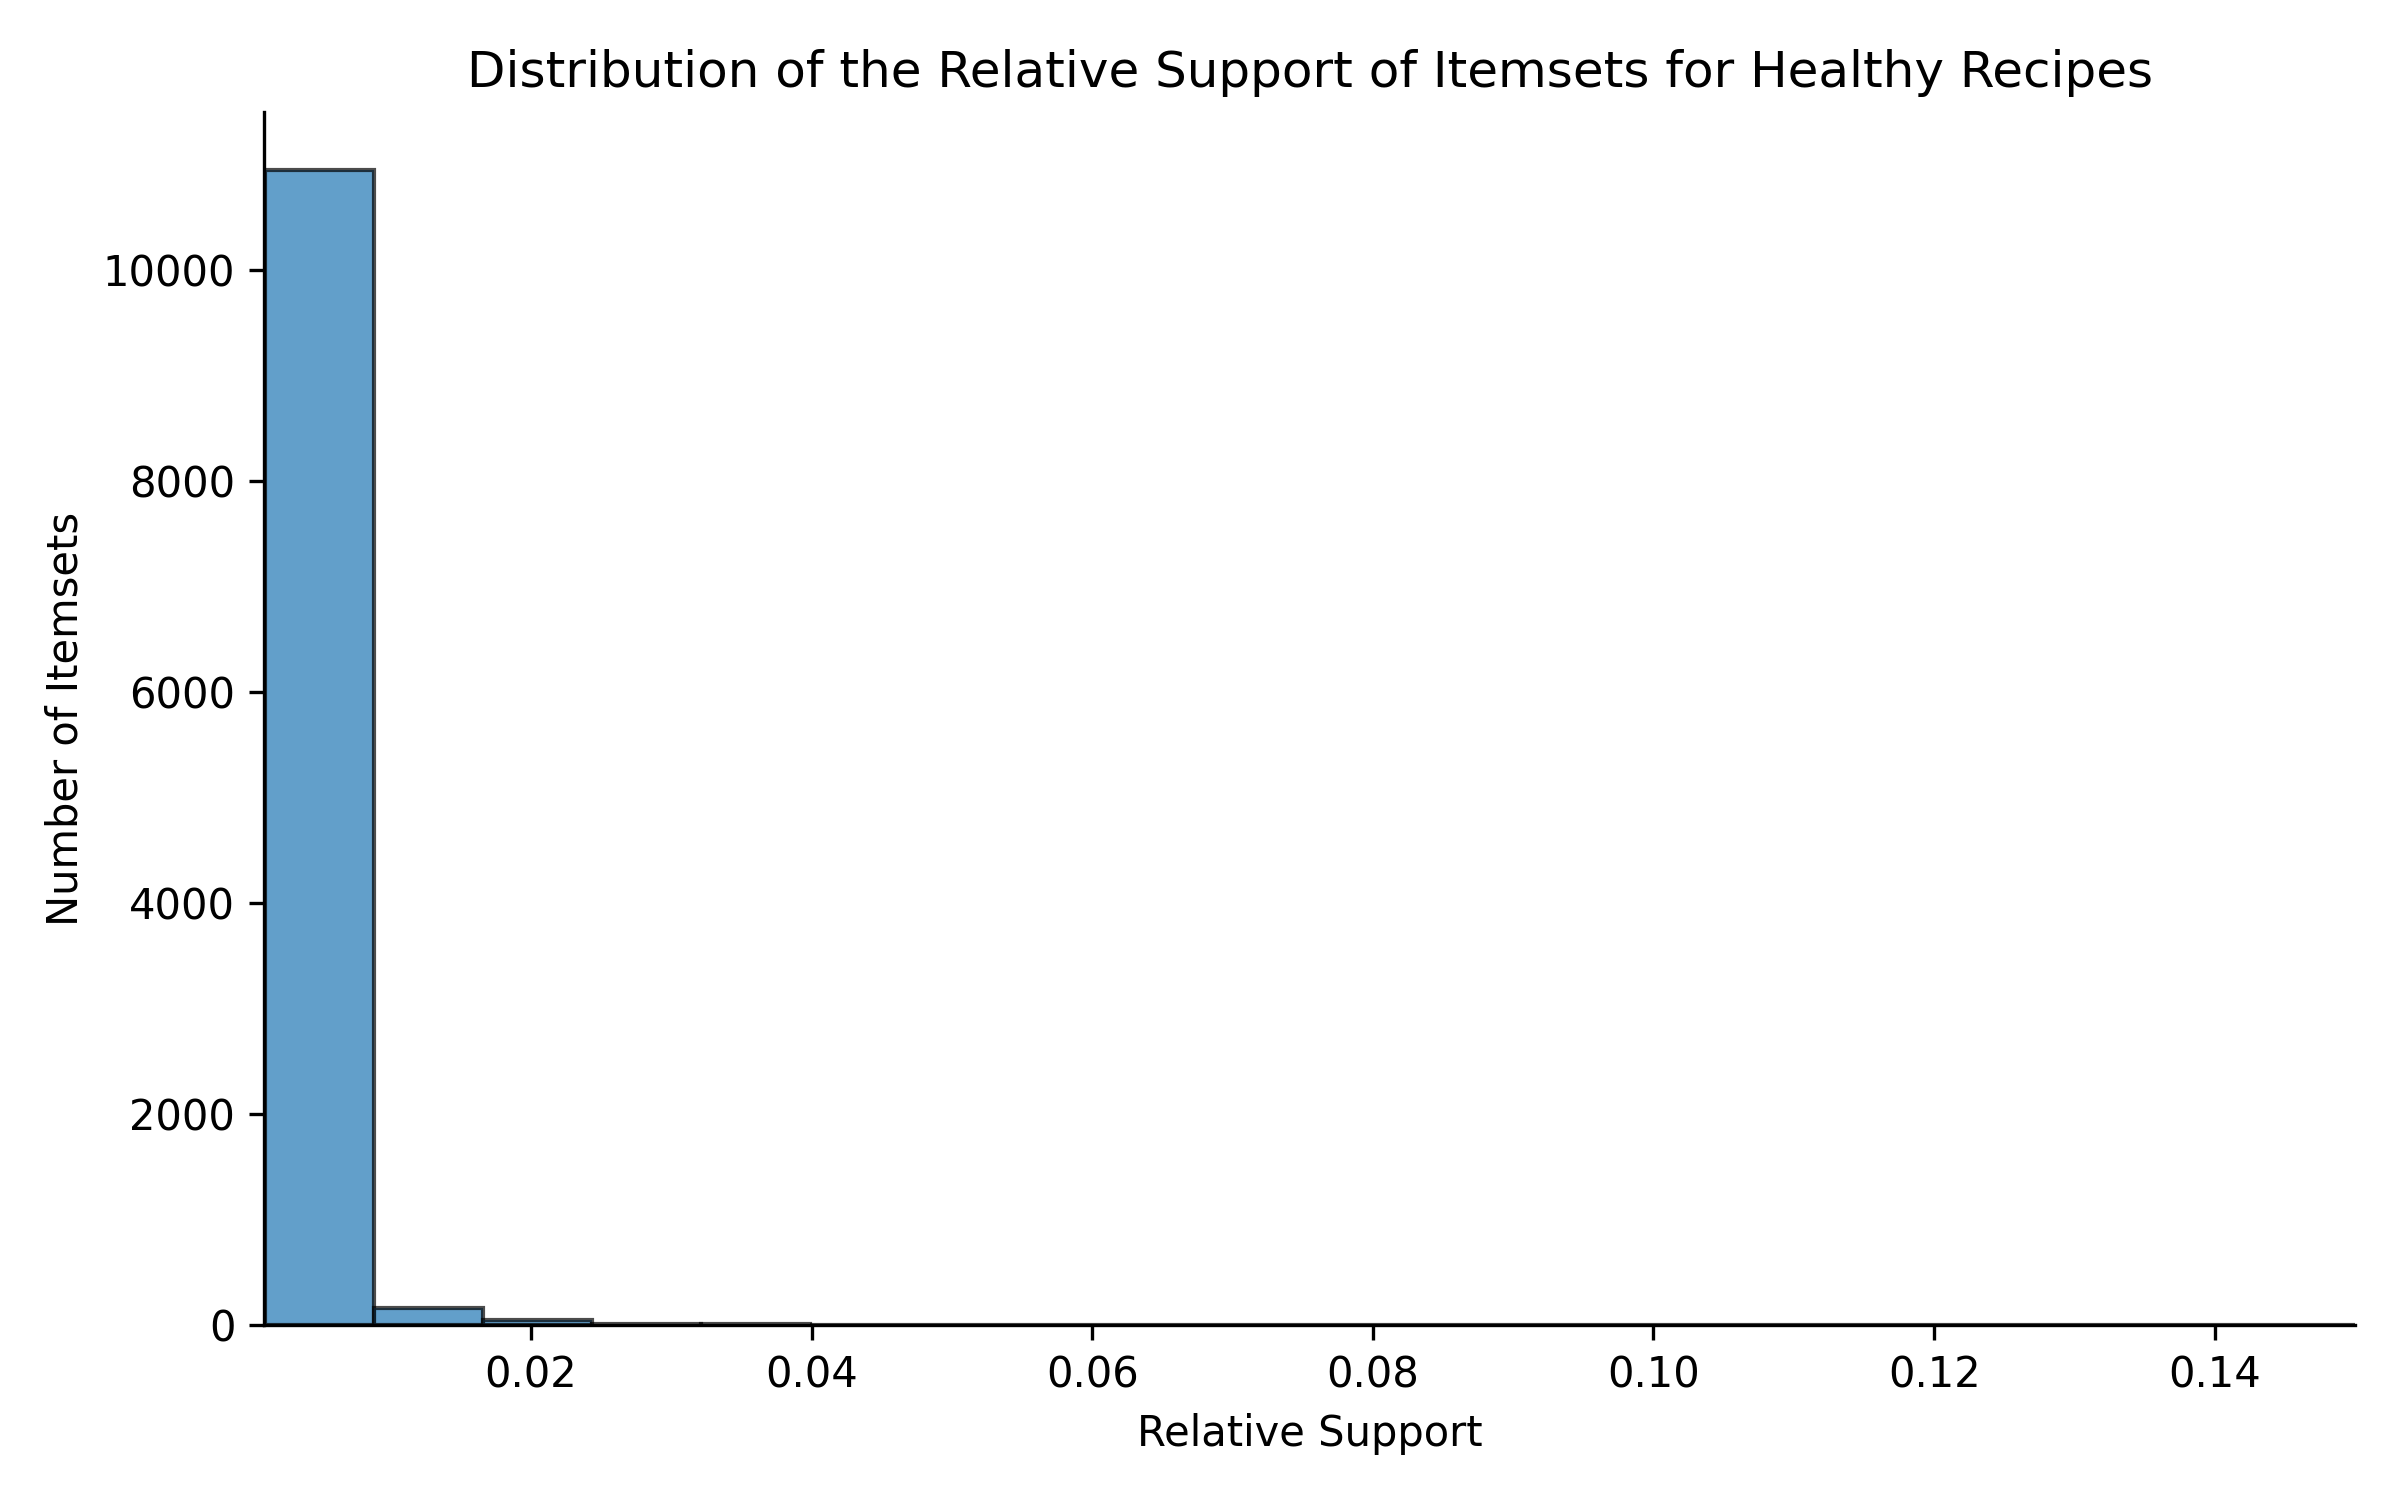

**Figure 5.** Distribution of the Relative Support of Itemsets for Healthy Recipes

In [11]:
fig_path = 'figures/relsup_healthy.png'

if os.path.exists(fig_path):
    display(Image(fig_path))
else:
    # --- Prepare transactions (list of ingredient lists) ---
    transactions = df_healthy['ingredients'].tolist()

    # --- Set minimum support threshold ---
    min_support = 0.001  # you can adjust this

    # --- Compute absolute minimum support count ---
    minsup_count = max(1, int(len(transactions) * min_support))

    # --- Find frequent itemsets ---
    patterns = pyfpgrowth.find_frequent_patterns(transactions, minsup_count)

    # --- Convert to DataFrame ---
    itemset_freq = pd.DataFrame({
        'itemset': list(patterns.keys()),
        'count': list(patterns.values())
    })
    itemset_freq['support'] = itemset_freq['count'] / len(df_healthy)

    # --- Filter supports (optional) ---
    itemset_freq = itemset_freq[itemset_freq['support'] >= 0.001]

    # --- Plot histogram ---
    plt.figure(figsize=(8, 5))
    plt.hist(itemset_freq['support'], bins=50, edgecolor='black', alpha=0.7)
    plt.title("Distribution of the Relative Support of Itemsets for Healthy Recipes")
    plt.xlabel("Relative Support")
    plt.ylabel("Number of Itemsets")

    # --- Adjust x-axis and layout ---
    plt.xlim(0.001, 0.15)
    plt.margins(x=0.02, y=0.05)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.savefig(fig_path, dpi=300)
    plt.show()

display(Markdown("**Figure 5.** Distribution of the Relative Support of Itemsets for Healthy Recipes"))

From the FIM, 227 frequent combinations were found, and the top 10 most frequent itemsets are listed in Table 5. We see that salt also dominates as a frequent ingredient across healthy recipes. Thus, it implies that salt also acts as a universal component in healthy recipes, enhancing flavor and preserving food.

<div align="center">

| Rank | Ingredients        | Support | Relative Support |
|------|-------------------|---------|-----------------|
| 1    | (salt,)            | 17,612  | 0.389749        |
| 2    | (sugar,)           | 10,060  | 0.222625        |
| 3    | (salt, sugar)      | 5,078   | 0.112375        |
| 4    | (salt, water)      | 4,458   | 0.098655        |
| 5    | (butter, salt)     | 3,379   | 0.074776        |
| 6    | (olive oil, salt)  | 3,240   | 0.071700        |
| 7    | (onion, salt)      | 3,237   | 0.071634        |
| 8    | (sugar, water)     | 2,939   | 0.065039        |
| 9    | (flour, salt)      | 2,887   | 0.063889        |
| 10   | (honey,)           | 2,649   | 0.058622        |

**Table 5.** Top 10 Most Frequent Ingredients Combinations for Healthy Recipes

</div>

Based on the chosen minimum support of 0.015, we generated the distribution of association rule confidence to get the optimal parameter of the minimum confidence. A minimum confidence of 0.75 was used because of similar reasoning from the previous section. Lift values were calculated to measure the strength of associations beyond random change. The top association rules for healthy recipes are listed below in Table 6.

<div align="center">

| Rank | Association Rule                       | Confidence | Lift |
|------|----------------------------------------|-----------|------|
| 1    | {'butter', 'pepper'} -> {'salt'}       | 0.87      | 2.38 |
| 2    | {'olive oil', 'pepper'} -> {'salt'}    | 0.84      | 2.31 |
| 3    | {'onion', 'pepper'} -> {'salt'}        | 0.83      | 2.27 |
| 4    | {'sugar', 'baking powder'} -> {'salt'} | 0.72      | 1.97 |
| 5    | {'sugar', 'all-purpose flour'} -> {'salt'} | 0.71  | 1.94 |

**Table 6.** Top 5 Rules with the Highest Lift for Healthy Recipes

</div>

Similar to the non-healthy foods, the association rules highlight consistent patterns among ingredients in healthy recipes. Salt is the consequent in all rules, which confirms that it is a universal base ingredient that enhances flavor even in health-conscious recipes. Moreover, the top rules indicate that when healthy ingredients like butter, olive oil, pepper, onion, sugar, baking powder, or all-purpose flour are present, salt is likely to be included as well. The confidence values ranging from 0.71 to 0.87, demonstrate a high likelihood of co-occurrence. while the lift values above 1.9 show that these are complementary products and associations are much stronger than expected. Overall, these rules highlight meaningful and significant ingredient combinations in healthy recipes.


<a id='Apply FIM'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">VII. Compare, Analyze, and Interpret the Results</h1>

To evaluate the similarity between the frequent ingredient itemsets of all recipes and those of healthy-only recipes, we used the Jaccard index as a similarity metric. The resulting similarity score of 0.45 indicates a moderate overlap between the two groups. This suggests that while many ingredient combinations are shared, a substantial portion of frequent itemsets in healthy recipes do not appear in non-healthy recipes, highlighting differences in ingredient usage patterns.


In [12]:
def jaccard_index(list1, list2):
    """Compute the Jaccard index between two lists."""
    set1 = set(list1)
    set2 = set(list2)

    # Avoid division by zero when both lists are empty
    if not set1 and not set2:
        return 0

    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union

min_support = 0.015
minsup_count = max(1, int(len(df_non_healthy) * min_support))

freq_itemsets = pyfpgrowth.find_frequent_patterns(df_non_healthy['ingredients'].to_list(),
                                                  minsup_count)

minsup_count = max(1, int(len(df_healthy) * min_support))                                             
healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(),
    minsup_count
)

jaccard_index(
    list(freq_itemsets.keys()),
    list(healthy_freq_ingredients.keys())
)


0.45132743362831856

Focusing specifically on the itemsets that occur exclusively in healthy recipes, which is shown in Table 7, patterns emerge that reflect healthier ingredient choices as shown in the table below. For example, vegetable oil and whole wheat flour appear in combinations that are absent from non-healthy recipes, indicating substitutions that reduce saturated fat and increase nutritional value (Das & Das, 2024). 

These findings show that healthy recipes preserve familiar flavors while prioritizing ingredients that support better nutritional profiles.


<div align="center">

| Rank | Ingredients                     | Support | Relative Support |
|------|--------------------------------|--------|----------------|
| 1    | (sugar,)                        | 10,060 | 0.222625       |
| 2    | (vegetable oil,)                 | 2,586  | 0.057228       |
| 3    | (flour, sugar)                   | 2,124  | 0.047004       |
| 4    | (milk, sugar)                    | 1,770  | 0.039170       |
| 5    | (eggs, sugar)                    | 1,576  | 0.034877       |
| 6    | (baking powder, baking soda)     | 1,328  | 0.029388       |
| 7    | (baking soda, sugar)             | 1,216  | 0.026910       |
| 8    | (all-purpose flour, baking powder)| 1,159 | 0.025648       |
| 9    | (whole wheat flour,)             | 1,151  | 0.025471       |
| 10   | (all-purpose flour, sugar)       | 1,141  | 0.025250       |

**Table 7.** Frequent Ingredient Combinations that Occurred ONLY in Healthy Recipes

</div>

<a id='Recommendation'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">VIII. RECOMMENDATION & LIMITATINS</h1>

<a id='Limitations'></a>
<h2 style="color:#ff9a00">A. Limitations of the Study</h2>

Within this study, several limitations are acknowledged. First, the data are derived from user-generated recipes, meaning that nutritional information, ingredient lists, and health-related tags are only as accurate as the contributors who entered them. This may lead to discrepancies when compared with verified nutritional data. Additionally, the classification of what constitutes a "healthy" recipe is largely determined by the platform, so tags such as "healthy" and "healthy-2" may not exactly align with standards set by nutrition experts or organizations like the DOH or WHO, particularly for elderly health.

The study also does not account for portion sizes or cooking methods. The presence of an ingredient in a recipe does not necessarily indicate the quantity used or the impact on overall nutritional content, and cooking methods such as frying or steaming can significantly alter caloric and nutrient values. While the FP-Growth algorithm is effective at identifying frequent patterns in the data, it cannot capture subtler aspects such as ingredient compatibility, culinary preferences, or consumer taste behavior.


<a id='Recommendation2'></a>
<h2 style="color:#ff9a00">B. Recommendation</h2>

From a business perspective, cookbook authors and recipe developers can leverage these findings to promote healthier recipes without sacrificing flavor. Specifically, four recommendations are provided:

Use the healthy tags to identify recipes that are generally more balanced, as shown by the histograms. These recipes tend to have lower saturated fats, sugar, and salt, making them suitable for promoting healthier eating habits.
1. Since salt is consistently used as a base ingredient, consider substituting it with healthier alternatives, such as low-sodium salts, herbs, or spices, to maintain flavor while improving nutritional quality.
2. Highlight natural sweeteners like honey, which frequently appear in healthy recipes, as substitutes for sugar. This allows recipes to remain appealing and flavorful while reducing added sugar content.
3. Reduce or substitute butter with healthier fat alternatives, such as olive oil, avocado, or nut butters. Olive oil, in particular, is already present in healthy recipes and serves as a familiar option that can lower saturated fat without compromising texture or taste, especially in baking or cooking applications.

From a technical perspective, future studies can strengthen the analysis by integrating nutritional attributes directly into the itemset mining process. In this study, nutritional data was only used as a sanity check to verify that healthy recipes were indeed more balanced. Incorporating these attributes into the FP-Growth framework itself, such as weighting itemsets based on nutrient content, would allow the discovery of ingredient combinations that are not only frequent but also nutritionally meaningful. 


<a id='Conclusion'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">IX. CONCLUSION</h1>

This study was able to accomplish its initial goal of conducting Frequent Item-set Mining on the Food.com Recipes dataset, to identify frequent ingredient patterns among healthy recipes. The main findings are that the top most common ingredients in the healthy category have mostly to do with baking recipes, as well as one from Mediterranean cuisine. When comparing the healthy recipes to all, the similarity of itemsets are around 52%. Despite the prevalence of baking ingredient itemsets, the total number of 3-ingredient itemsets decrease when filtering for healthier recipes. Meaning they are either simpler or have a more varied ingredient profile. Notably the strongest association rule pattern has salt as its consequent, meaning that even while a dish is healthy, it is still important to flavor the dish with salt. Overall, these findings are able to give a notable first step towards developing healthier meal recommendations for the senior population

<a id='References'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">ACKNOWLEDGEMENTS</h1>

The team would like to acknowledge Food.com as the original source of the reviews and the Asian Institute of Management's "jojie-collected" repository for compiling and sharing the food-com-recipes dataset for public educational use. They would like to express their sincere appreciation to their learning team members and Professor Christian M. Alis for their invaluable guidance and support in completing this report. The group also acknowledges their use of Artificial Intelligence, such as ChatGPT. 


<a id='References'></a>
<h1 style="color:#ffffff; background-color:#222f3e; border: 1px solid #ffffff; padding: 10px 0;">REFERENCES</h1>

American Heart Association. (2024, August 23). Dietary Fats. Dietary Fats.  
  Retrieved November 11, 2025, from https://www.heart.org/en/healthy-living/healthy-eating/eat-smart/fats/dietary-fats

Das, M., Das, A. A comprehensive review on strategies for replacing saturated fats in bakery products. Discov Food 4, 156 (2024).  
  https://doi.org/10.1007/s44187-024-00240-2

Dietary Guidelines for Americans. (2025). Make Every Bite Count With the Dietary Guidelines.  
  Retrieved November 11, 2025, from https://www.dietaryguidelines.gov/sites/default/files/2020-12/Dietary_Guidelines_for_Americans_2020-2025.pdf

Gumaru, M. (n.d.). Daily Nutritional Guide Pyramid. FNRI Website.  
  https://fnri.dost.gov.ph/index.php/tools-and-standard/nutritional-guide-pyramid

World Health Organization (2025). Healthy diet. World Health Organization.  
  https://www.who.int/news-room/fact-sheets/detail/healthy-diet


***
**END**